In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import mne
from scipy.signal import welch
from specparam import SpectralModel
from specparam.utils.download import load_example_data
from specparam.metrics.definitions import check_metrics
import pandas as pd
import warnings
from neurodsp.sim import sim_synaptic_current
from neurodsp.utils import create_times
from neurodsp.filt import filter_signal
from neurodsp.spectral import compute_spectrum
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.formula.api import ols
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

import mne
mne.set_log_level('CRITICAL')

In [2]:
DATA_DIR = Path('/Users/KeanuVentura/Desktop/sesdata')

results = {}

for i in range(1, 128):
    sub_id = f"sub-{i:03d}"
    file_path = DATA_DIR / f"subject{i:03d}" / f"{sub_id}_task-flanker_eeg.vhdr"

    if not file_path.exists():
        print(f"{sub_id}: file not found, skipping")
        continue

    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        raw.pick('eeg')
        raw.notch_filter(
            freqs=np.arange(58, 63),
            method='spectrum_fit',
            n_jobs=-1,
            verbose=False
        )
        
        fs = raw.info['sfreq']
        events, event_id = mne.events_from_annotations(raw)
        event_id_clean = {
            k.split('/')[-1].replace("S", "").strip(): v
            for k, v in event_id.items()
        }
        incongruent_keys = ['21', '22']
        incong_event_id = {
            k: event_id_clean[k] for k in incongruent_keys if k in event_id_clean
        }

        if len(incong_event_id) == 0:
            print(f"{sub_id}: no incongruent events, skipping")
            continue

        stim_event_values = list(incong_event_id.values())
        stim_events = events[np.isin(events[:, 2], stim_event_values)]

        if len(stim_events) == 0:
            print(f"{sub_id}: no valid trials, skipping")
            continue

        events_corrected = stim_events.copy()
        events_corrected[:, 0] += int(0.02 * fs)

        epochs = mne.Epochs(
            raw,
            events_corrected,
            event_id=incong_event_id,
            tmin=-0.5,
            tmax=0.6,
            baseline=None,
            preload=True,
            verbose=False
        )
        epochs = epochs.pick(['Pz'])

        if len(epochs) == 0:
            print(f"{sub_id}: empty epochs, skipping")
            continue

        data = epochs.get_data()[:, 0, :]
        times = epochs.times * 1000

        pre_mask = (times >= -500) & (times <= 0)

        # Concatenate pre-stimulus segments across all trials, then compute one PSD.
        # More stable than averaging per-trial PSDs — matches how post is handled.
        all_pre_concat = data[:, pre_mask].flatten()
        freqs, psd_pre = welch(
            all_pre_concat,
            fs=fs,
            nperseg=int(2 * fs)
        )
        mask = (freqs >= 1) & (freqs <= 40)
        freqs = freqs[mask]
        psd_pre = psd_pre[mask]

        fm = SpectralModel(aperiodic_mode='fixed', verbose=False)
        fm.fit(freqs, psd_pre)
        exp_pre = fm.get_params('aperiodic', 'exponent')
        off_pre = fm.get_params('aperiodic', 'offset')

        post_mask = (times >= 300) & (times <= 600)
        all_post = data[:, post_mask].flatten()
        freqs, psd = welch(
            all_post,
            fs=fs,
            nperseg=int(1 * fs)
        )
        mask = (freqs >= 1) & (freqs <= 40)
        freqs = freqs[mask]
        psd = psd[mask]

        fm = SpectralModel(aperiodic_mode='fixed', verbose=False)
        fm.fit(freqs, psd)
        exp_post = fm.get_params('aperiodic', 'exponent')
        off_post = fm.get_params('aperiodic', 'offset')

        epochs_erp = mne.Epochs(
            raw,
            events_corrected,
            event_id=incong_event_id,
            tmin=-0.5,
            tmax=0.6,
            baseline=(-0.2, 0),
            preload=True,
            verbose=False
        )
        epochs_erp = epochs_erp.pick(['Pz'])
        data_erp = epochs_erp.get_data()[:, 0, :]

        p3b_mask = (times >= 300) & (times <= 600)
        p3b_amp = data_erp[:, p3b_mask].mean(axis=1).mean()

        results[sub_id] = {
            'exp_pre': exp_pre,
            'off_pre': off_pre,
            'exp_post': exp_post,
            'off_post': off_post,
            'p3b_amp': p3b_amp
        }

        print(f"{sub_id}: done")

    except Exception as e:
        print(f"{sub_id}: ERROR → {e}")
        continue

df = pd.DataFrame.from_dict(results, orient='index')
df.index.name = 'subject'

sub-001: done
sub-002: done
sub-003: done
sub-004: done
sub-005: done
sub-006: done
sub-007: done
sub-008: done
sub-009: done
sub-010: done
sub-011: done
sub-012: done
sub-013: done
sub-014: done
sub-015: done
sub-016: done
sub-017: done
sub-018: done
sub-019: done
sub-020: done
sub-021: done
sub-022: done
sub-023: done
sub-024: done
sub-025: done
sub-026: done
sub-027: done
sub-028: done
sub-029: done
sub-030: done
sub-031: done
sub-032: done
sub-033: done
sub-034: done
sub-035: done
sub-036: done
sub-037: done
sub-038: done
sub-039: done
sub-040: done
sub-041: done
sub-042: done
sub-043: done
sub-044: done
sub-045: done
sub-046: done
sub-047: done
sub-048: done
sub-049: done
sub-050: done
sub-051: done
sub-052: done
sub-053: done
sub-054: done
sub-055: done
sub-056: done
sub-057: done
sub-058: done
sub-059: done
sub-060: done
sub-061: done
sub-062: done
sub-063: done
sub-064: done
sub-065: done
sub-066: done
sub-067: done
sub-068: done
sub-069: done
sub-070: done
sub-071: done
sub-07

In [3]:
df.head()

,exp_pre,off_pre,exp_post,off_post,p3b_amp
subject,,,,,
sub-001,1.931768,-9.418345,2.057616,-9.037435,5.333927e-06
sub-002,1.594747,-10.694341,1.835616,-10.265643,-3.117996e-06
sub-003,1.751514,-10.269298,1.901003,-9.932735,2.343752e-06
sub-004,1.594511,-10.671927,1.787019,-10.358590,-4.291795e-07
sub-005,1.954636,-9.697376,1.980872,-9.329237,8.826302e-07


In [4]:
import pandas as pd

participants = pd.read_csv("participants.txt", sep='\t')

participants_clean = participants[[
    'participant_id',
    'Subjective_SES', # self-reported childhood ses
    "Highest_Edu_Grouped",
    'Highest_Adult_Edu_Grouped',
    'Age_Grouped',
    'Gender',
    'FlankerEEG', # whether they participated in flanker
    'fs1', 'fs2', 'fs3', 'fs4', 'fs5', 'fs6', # food security
    'hnc1a', 'hnc1b', 'hnc1c', 'hnc1d', # home neighbordhood characteristics
    'hnc2a', 'hnc2b',
    'hnc3', 'hnc4',
    'ADHD_binary'
]]

edu_map = {
    "High School or Less": 0,
    "High School": 1,
    "Some College or Associate Degree": 2,
    "Bachelor's Degree or Higher": 3
}

participants_clean['edu'] = participants_clean[
    "Highest_Edu_Grouped"
].map(edu_map)

participants_clean['parent_edu'] = participants_clean[
    'Highest_Adult_Edu_Grouped'
].map(edu_map)

fs_map = {
    "often true": 2,
    "sometimes true": 1,
    "never true": 0,
    "yes": 1,
    "no": 0,
    "only 1 to 2 months": 1,
    "some months but not every month": 1,
    "almost every month": 2
}

for col in ['fs1','fs2','fs3','fs4','fs5','fs6']:
    participants_clean[col] = participants_clean[col].map(fs_map)

participants_clean['food_insecurity'] = participants_clean[
    ['fs1','fs2','fs3','fs4','fs5','fs6']
].mean(axis=1)

hnc_binary_map = {
    "yes": 1,
    "no": 0
}

for col in ['hnc1a','hnc1b','hnc1c','hnc1d','hnc2a','hnc2b','hnc3']:
    participants_clean[col] = participants_clean[col].map(hnc_binary_map)

hnc4_map = {
    "very safe": 0,
    "somewhat safe": 1,
    "somewhat unsafe": 2,
    "very unsafe": 3
}

participants_clean['hnc4'] = participants_clean['hnc4'].map(hnc4_map)

participants_clean['neighborhood_score'] = participants_clean[
    ['hnc1a','hnc1b','hnc1c','hnc1d','hnc2a','hnc2b','hnc3','hnc4']
].mean(axis=1)

"""
participants_clean['gender_binary'] = participants_clean['Gender'].map({
    'male': 0,
    'female': 1
})
"""

participants_clean = participants_clean[participants_clean['FlankerEEG'] == 1]

df_clean = df.reset_index().rename(columns={'subject': 'participant_id'})

df_final = df_clean.merge(
    participants_clean,
    on='participant_id'
)

df_final['p3b_amp'] = df_final['p3b_amp'] * 1e6

df_final = df_final[[
    'participant_id',
    'p3b_amp',
    'exp_pre', 'exp_post',
    'off_pre', 'off_post',

    'Subjective_SES',
    'edu',
    'parent_edu',
    'food_insecurity',
    'neighborhood_score',

    'Age_Grouped',
    'Gender', 
    'ADHD_binary'
]]

df_final = df_final.set_index('participant_id')
df_final

,p3b_amp,exp_pre,exp_post,off_pre,off_post,Subjective_SES,edu,parent_edu,food_insecurity,neighborhood_score,Age_Grouped,Gender,ADHD_binary
participant_id,,,,,,,,,,,,,
sub-001,5.333927,1.931768,2.057616,-9.418345,-9.037435,5.0,1,2,1.166667,0.125,18 to 22,female,0.0
sub-002,-3.117996,1.594747,1.835616,-10.694341,-10.265643,3.0,3,2,0.333333,0.125,23 to 26,male,0.0
sub-003,2.343752,1.751514,1.901003,-10.269298,-9.932735,7.0,1,3,0.666667,0.625,18 to 22,female,1.0
sub-004,-0.429180,1.594511,1.787019,-10.671927,-10.358590,3.0,1,3,0.833333,0.875,18 to 22,female,0.0
sub-005,0.882630,1.954636,1.980872,-9.697376,-9.329237,6.0,2,0,0.000000,0.000,18 to 22,male,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
sub-069,2.298559,2.057525,2.053259,-9.234872,-8.992250,4.0,3,0,0.000000,0.000,18 to 22,male,0.0
sub-070,-5.058198,1.598661,1.676583,-10.529466,-10.391860,1.0,2,0,NaN,NaN,23 to 26,male,NaN
sub-071,1.566541,2.032541,2.040579,-9.330546,-9.097673,7.0,2,3,0.000000,0.375,23 to 26,male,NaN


### Variable Definitions

* **participant_id**
  Subject

* **p3b_amp**
  Average ERP amplitude at electrode Pz from 300–600 ms post-stimulus

* **exp_pre**
  Aperiodic exponent (spectral slope) from EEG power spectrum during pre-stimulus window (−500 to 0 ms); reflects baseline neural state

* **exp_post**
  Aperiodic exponent during post-stimulus window (300–600 ms); reflects task-evoked neural state

* **off_pre**
  Aperiodic offset (broadband power level) during pre-stimulus window (−500 to 0 ms)

* **off_post**
  Aperiodic offset during post-stimulus window (300–600 ms)

* **Subjective_SES**
  Self-reported childhood socioeconomic status (ordinal scale; higher values indicate higher perceived status)

* **edu**
  Participant’s own education level (ordinal):

  * 0 = High School or Less
  * 1 = High School
  * 2 = Some College or Associate Degree
  * 3 = Bachelor’s Degree or Higher

* **parent_edu**
  Highest parental/guardian education level during childhood (ordinal proxy for objective SES):

  * 0 = High School or Less
  * 1 = High School
  * 2 = Some College or Associate Degree
  * 3 = Bachelor’s Degree or Higher

* **food_insecurity**
  Mean score across six food security items (fs1–fs6) assessing access to adequate food

  * 0 = no insecurity (e.g., “never true”, “no”)
  * 1 = moderate insecurity (e.g., “sometimes true”, occasional months)
  * 2 = high insecurity (e.g., “often true”, frequent occurrence)
    Higher values indicate greater food insecurity

* **neighborhood_score**
  Mean score across eight housing and neighborhood condition items (hnc1a–hnc4) assessing environmental quality

  * Binary items (housing/neighborhood problems): 0 = no problem, 1 = problem present
  * Safety perception: 0 = very safe → 3 = very unsafe
    Higher values indicate worse housing and neighborhood conditions

* **Age_Grouped**
  Participant age category (e.g., 18–22, 23–26)

* **Gender**
  Self-reported gender (male/female)


run a prelim linear regression model with 3 subjects. the analysis we are going to do. predict p3b amplitude based on covariates. Age group and gender. show what the data tells us so far. gender and age is fixed. post - pre is delta. predict amplitude with offset and predict with exponent. set up regular models,set up delta models. download some more subject data. think about a presentation of this. what information needed. literature reviews further use literature reviews given. what is ses what contributes to high vs low. start roguh slides. present to lab in the fall. SFN society for neurocience conference. May 27th abstract submision, deadline is june 10th. 500 words short dont need results yet. rough draft in 2 weeks. use liz's abstracts for reference. notch filter mne 58-62. external drive for ses data. Ethan Erickson, email brad, what hours look like, do you have to work 12 per week, up to an amount

In [5]:
# exponent prelim model

In [6]:
df_model = df_final.copy()

df_model['Age_Grouped'] = df_model['Age_Grouped'].astype('category')
df_model['Gender'] = df_model['Gender'].astype('category')

model_exp = smf.ols(
    'p3b_amp ~ exp_post * parent_edu + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_exp.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     2.211
Date:                Tue, 02 Jun 2026   Prob (F-statistic):             0.0528
Time:                        09:51:28   Log-Likelihood:                -183.06
No. Observations:                  73   AIC:                             380.1
Df Residuals:                      66   BIC:                             396.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

Preliminary results suggest a potential interaction between aperiodic exponent and SES. Results suggest that for HIGH SES subjects, the relationship between exponent and P3b is more positive. Males have lower P3b amplitude than females (already proven).

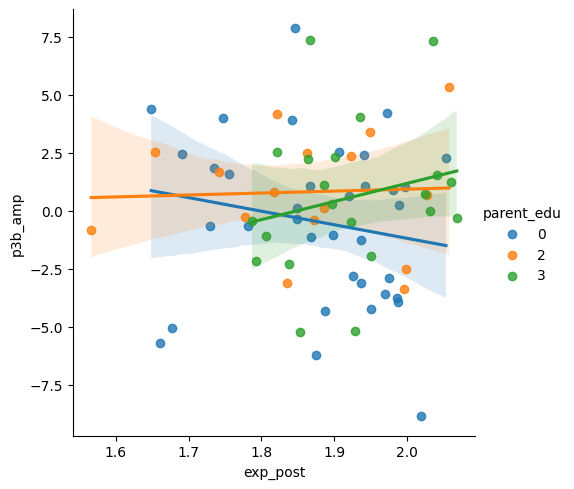

In [7]:
import seaborn as sns

sns.lmplot(
    x='exp_post',
    y='p3b_amp',
    hue='parent_edu',
    data=df_model
)

In [10]:
# offset prelim model

In [8]:
model_off = smf.ols(
    'p3b_amp ~ off_post * parent_edu + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_off.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     3.142
Date:                Tue, 02 Jun 2026   Prob (F-statistic):            0.00902
Time:                        09:54:49   Log-Likelihood:                -180.57
No. Observations:                  73   AIC:                             375.1
Df Residuals:                      66   BIC:                             391.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

Model is more statistically significant overall than the first. The interaction term off_post:parent_edu[T.high] is statistically significant! Model also suggests that higher aperiodic offset → higher P3b amplitude. 

Main takeaway: SES significantly moderates the relationship between broadband neural activity (offset) and cognitive processing (P3b)

The relationship between aperiodic offset and P3b amplitude differed significantly across SES groups, with higher SES individuals showing a stronger positive association between offset and P3b amplitude.

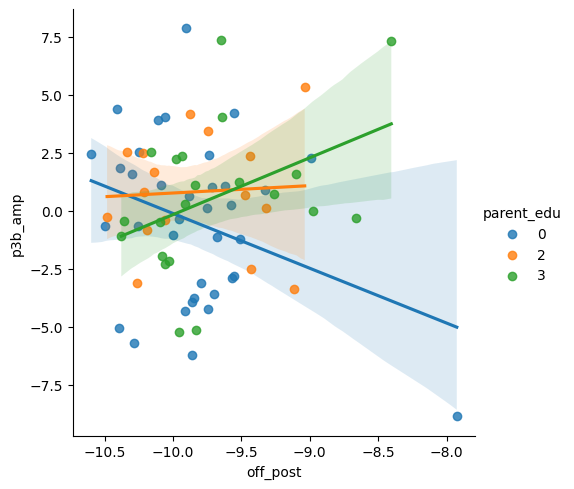

In [9]:
import seaborn as sns

sns.lmplot(
    x='off_post',
    y='p3b_amp',
    hue='parent_edu',
    data=df_model
)

In [13]:
# exponent and offset prelim model

In [10]:
model_combined = smf.ols(
    'p3b_amp ~ parent_edu * exp_post * off_post + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_combined.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     1.990
Date:                Tue, 02 Jun 2026   Prob (F-statistic):             0.0496
Time:                        09:55:15   Log-Likelihood:                -179.58
No. Observations:                  73   AIC:                             381.2
Df Residuals:                      62   BIC:                             406.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [11]:
model_combined = smf.ols(
    'p3b_amp ~ exp_post * parent_edu + off_post * parent_edu + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_combined.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     2.476
Date:                Tue, 02 Jun 2026   Prob (F-statistic):             0.0209
Time:                        09:55:15   Log-Likelihood:                -179.90
No. Observations:                  73   AIC:                             377.8
Df Residuals:                      64   BIC:                             398.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

The predictive relationship between aperiodic offset and P3b amplitude is weakened when controlling for exponent, likely due to shared variance between the two measures. Lots of multicollinearity because exp_post and off_post are strongly correlated.

Main takeaway: The condition number is large, 1.98e+03. This might indicate that there are
strong multicollinearity or other numerical problems.

In [16]:
# delta diff models

In [17]:
# delta exponent model

In [12]:
df_model['delta_exp'] = df_model['exp_post'] - df_model['exp_pre']

model_delta_exp = smf.ols(
    'p3b_amp ~ delta_exp * parent_edu + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_delta_exp.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     3.352
Date:                Tue, 02 Jun 2026   Prob (F-statistic):            0.00606
Time:                        09:55:48   Log-Likelihood:                -180.03
No. Observations:                  73   AIC:                             374.1
Df Residuals:                      66   BIC:                             390.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

exponent kinda stinks

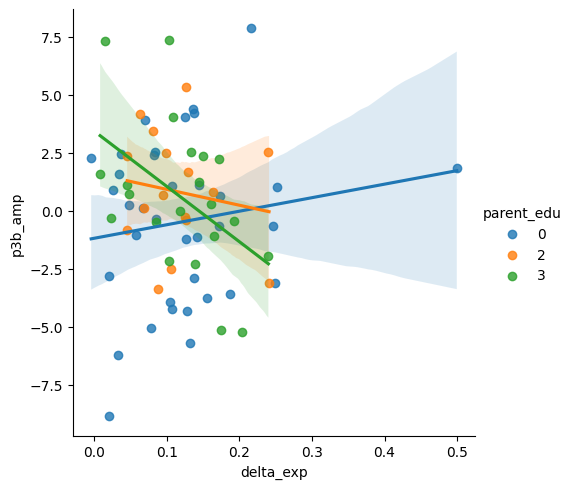

In [13]:
sns.lmplot(
    x='delta_exp',
    y='p3b_amp',
    hue='parent_edu',
    data=df_model
)

In [14]:
# delta offset model

In [15]:
df_model['delta_off'] = df_model['off_post'] - df_model['off_pre']

model_delta_off = smf.ols(
    'p3b_amp ~ delta_off * parent_edu + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_delta_off.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     2.057
Date:                Tue, 02 Jun 2026   Prob (F-statistic):             0.0703
Time:                        09:56:05   Log-Likelihood:                -183.48
No. Observations:                  73   AIC:                             381.0
Df Residuals:                      66   BIC:                             397.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

For HIGH SES individuals, greater increase in offset (post − pre) → higher P3b amplitude and for LOW SES delta_off effect ≈ negative / weak. High SES differs from low SES in baseline P3b

Main Takeaway: Not only does SES change static brain relationships, but SES moderates how brain activity changes over time. SES affects how the brain responds to a stimulus, not just baseline brain activity.

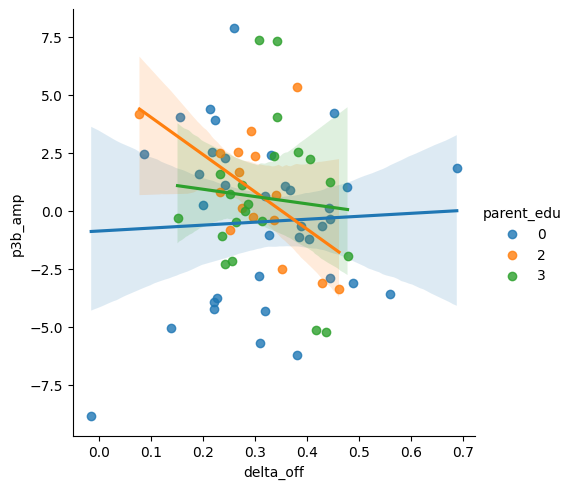

In [16]:
sns.lmplot(
    x='delta_off',
    y='p3b_amp',
    hue='parent_edu',
    data=df_model
)

In [17]:
# used cooks distance to identify influential data points in regression analysis

In [18]:
influence = OLSInfluence(model_delta_off)

threshold = 4 / len(df_final)

outliers = influence.summary_frame()[
    influence.summary_frame()['cooks_d'] > threshold
]

outliers

df_clean = df_model.drop(outliers.index)
df_clean


,p3b_amp,exp_pre,exp_post,off_pre,off_post,Subjective_SES,edu,parent_edu,food_insecurity,neighborhood_score,Age_Grouped,Gender,ADHD_binary,delta_exp,delta_off
participant_id,,,,,,,,,,,,,,,
sub-001,5.333927,1.931768,2.057616,-9.418345,-9.037435,5.0,1,2,1.166667,0.125,18 to 22,female,0.0,0.125848,0.380910
sub-002,-3.117996,1.594747,1.835616,-10.694341,-10.265643,3.0,3,2,0.333333,0.125,23 to 26,male,0.0,0.240869,0.428698
sub-003,2.343752,1.751514,1.901003,-10.269298,-9.932735,7.0,1,3,0.666667,0.625,18 to 22,female,1.0,0.149488,0.336562
sub-004,-0.429180,1.594511,1.787019,-10.671927,-10.358590,3.0,1,3,0.833333,0.875,18 to 22,female,0.0,0.192508,0.313337
sub-005,0.882630,1.954636,1.980872,-9.697376,-9.329237,6.0,2,0,0.000000,0.000,18 to 22,male,0.0,0.026235,0.368139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sub-069,2.298559,2.057525,2.053259,-9.234872,-8.992250,4.0,3,0,0.000000,0.000,18 to 22,male,0.0,-0.004266,0.242622
sub-070,-5.058198,1.598661,1.676583,-10.529466,-10.391860,1.0,2,0,NaN,NaN,23 to 26,male,NaN,0.077922,0.137606
sub-071,1.566541,2.032541,2.040579,-9.330546,-9.097673,7.0,2,3,0.000000,0.375,23 to 26,male,NaN,0.008037,0.232873


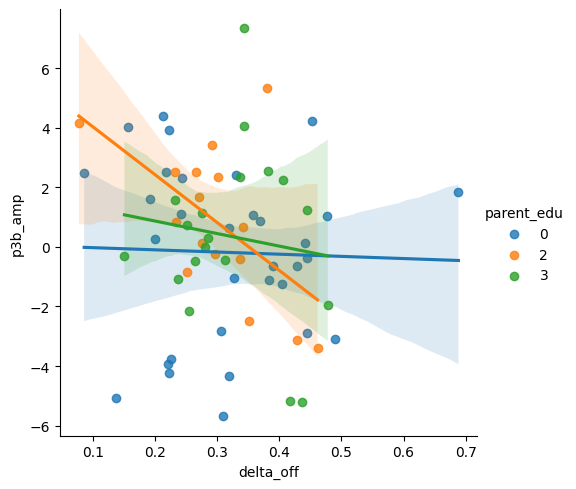

In [19]:
sns.lmplot(
    x='delta_off',
    y='p3b_amp',
    hue='parent_edu',
    data=df_clean
)

In [20]:
# still another outlier that had a p3b amp and delta off way too high

In [21]:
df_clean.sort_values(by=['delta_off', 'p3b_amp'], ascending=False).head(1)

,p3b_amp,exp_pre,exp_post,off_pre,off_post,Subjective_SES,edu,parent_edu,food_insecurity,neighborhood_score,Age_Grouped,Gender,ADHD_binary,delta_exp,delta_off
participant_id,,,,,,,,,,,,,,,
sub-060,1.839829,1.235181,1.734802,-11.073103,-10.384755,1.0,3,0,0.0,0.125,27 to 30,female,1.0,0.499622,0.688349


In [22]:
df_clean = df_clean.drop('sub-030')
df_clean

,p3b_amp,exp_pre,exp_post,off_pre,off_post,Subjective_SES,edu,parent_edu,food_insecurity,neighborhood_score,Age_Grouped,Gender,ADHD_binary,delta_exp,delta_off
participant_id,,,,,,,,,,,,,,,
sub-001,5.333927,1.931768,2.057616,-9.418345,-9.037435,5.0,1,2,1.166667,0.125,18 to 22,female,0.0,0.125848,0.380910
sub-002,-3.117996,1.594747,1.835616,-10.694341,-10.265643,3.0,3,2,0.333333,0.125,23 to 26,male,0.0,0.240869,0.428698
sub-003,2.343752,1.751514,1.901003,-10.269298,-9.932735,7.0,1,3,0.666667,0.625,18 to 22,female,1.0,0.149488,0.336562
sub-004,-0.429180,1.594511,1.787019,-10.671927,-10.358590,3.0,1,3,0.833333,0.875,18 to 22,female,0.0,0.192508,0.313337
sub-005,0.882630,1.954636,1.980872,-9.697376,-9.329237,6.0,2,0,0.000000,0.000,18 to 22,male,0.0,0.026235,0.368139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sub-069,2.298559,2.057525,2.053259,-9.234872,-8.992250,4.0,3,0,0.000000,0.000,18 to 22,male,0.0,-0.004266,0.242622
sub-070,-5.058198,1.598661,1.676583,-10.529466,-10.391860,1.0,2,0,NaN,NaN,23 to 26,male,NaN,0.077922,0.137606
sub-071,1.566541,2.032541,2.040579,-9.330546,-9.097673,7.0,2,3,0.000000,0.375,23 to 26,male,NaN,0.008037,0.232873


In [23]:
model_final = smf.ols(
    'p3b_amp ~ delta_off * parent_edu + Age_Grouped + Gender',
    data=df_clean
).fit()

print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     1.825
Date:                Tue, 02 Jun 2026   Prob (F-statistic):              0.110
Time:                        09:56:53   Log-Likelihood:                -152.71
No. Observations:                  66   AIC:                             319.4
Df Residuals:                      59   BIC:                             334.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

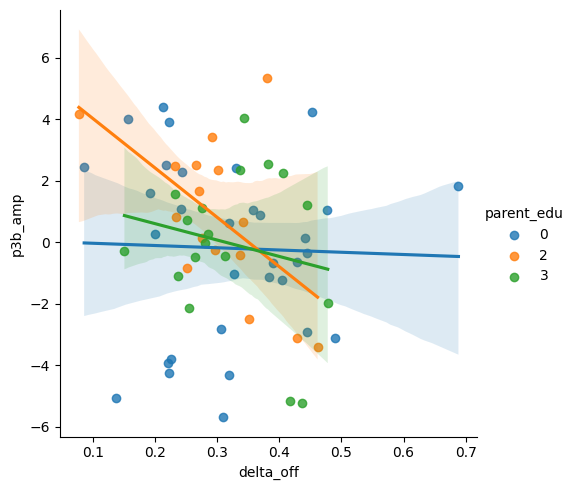

In [24]:
sns.lmplot(
    x='delta_off',
    y='p3b_amp',
    hue='parent_edu',
    data=df_clean
)

In [25]:
# do SES groups differ in aperiodic dynamics? --> ANOVA tests

In [26]:
model = ols(
    'exp_post ~ C(parent_edu) + C(Gender) + C(Age_Grouped)',
    data=df_clean
).fit()

sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(parent_edu),0.009954,2.0,0.413331,0.663312
C(Gender),0.025135,1.0,2.087467,0.153715
C(Age_Grouped),0.072131,2.0,2.995202,0.057559
Residual,0.722466,60.0,NaN,NaN


In [27]:
# there is no significant difference in post-stimulus exponent across SES groups

In [28]:
model = ols(
    'exp_pre ~ C(parent_edu) + C(Gender) + C(Age_Grouped)',
    data=df_clean
).fit()

sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(parent_edu),0.001544,2.0,0.037676,0.963047
C(Gender),0.099253,1.0,4.844206,0.031598
C(Age_Grouped),0.170716,2.0,4.166055,0.020221
Residual,1.229339,60.0,NaN,NaN


In [29]:
# there is no significant difference in pre-stimulus exponent across SES groups

In [30]:
model = ols(
    'off_post ~ C(parent_edu) + C(Gender) + C(Age_Grouped)',
    data=df_clean
).fit()

sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(parent_edu),0.046521,2.0,0.150211,0.860849
C(Gender),1.203463,1.0,7.771791,0.007098
C(Age_Grouped),1.094864,2.0,3.535235,0.035367
Residual,9.291011,60.0,NaN,NaN


In [31]:
# there is no significant difference in post-stimulus offset across SES groups, gender significant though

In [32]:
model = ols(
    'off_pre ~ C(parent_edu) + C(Gender) + C(Age_Grouped)',
    data=df_clean
).fit()

sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(parent_edu),0.087446,2.0,0.278723,0.757724
C(Gender),1.059621,1.0,6.754836,0.011749
C(Age_Grouped),1.291729,2.0,4.117234,0.021107
Residual,9.412111,60.0,NaN,NaN


In [33]:
# there are significant differences in pre-stimulus aperiodic activity across SES groups -> SES DOES affect baseline aperiodic offset

In [34]:
model = ols(
    'delta_off ~ C(parent_edu) + C(Gender) + C(Age_Grouped)',
    data=df_clean
).fit()

sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(parent_edu),0.006419,2.0,0.274726,0.760731
C(Gender),0.004576,1.0,0.391715,0.533773
C(Age_Grouped),0.054792,2.0,2.345183,0.104556
Residual,0.700910,60.0,NaN,NaN


In [35]:
# SES does NOT affect change in aperiodic offset, but gender significant

In [36]:
# explore gender differences

In [37]:
df_clean.groupby('Gender')[['exp_pre', 'off_pre', 'exp_post', 'off_post', 'delta_exp', 'delta_off']].mean()

,exp_pre,off_pre,exp_post,off_post,delta_exp,delta_off
Gender,,,,,,
female,1.722917,-10.288779,1.860849,-9.976057,0.137932,0.312722
male,1.807457,-10.015288,1.910060,-9.695635,0.102603,0.319653


In [38]:
# males show higher post-stimulus offset and larger increases in offset compared to females
# males exhibit greater broadband neural activity and larger stimulus-related increases in aperiodic offset compared to females


In [39]:
from scipy.stats import pearsonr

results = []

for group in ['low', 'mid', 'high']:
    df_group = df_clean[df_clean['parent_edu'] == group]
    
    for var in ['exp_pre', 'exp_post', 'off_pre', 'off_post', 'delta_exp', 'delta_off']:
        r, p = pearsonr(df_group[var], df_group['p3b_amp'])
        r2 = r**2
        
        results.append({
            'parent_edu': group,
            'variable': var,
            'r': r,
            'R_squared': r2,
            'p_value': p
        })

import pandas as pd
df_corr = pd.DataFrame(results)
df_corr

ValueError: `x` and `y` must have length at least 2.

In [ ]:
df_corr.sort_values('p_value').iloc[0:2]

In [40]:
# preliminary analyses suggest SES-dependent variability in the relationship between aperiodic activity and P3b amplitude, with stronger 
# associations observed in mid and high SES groups relative to low SES.

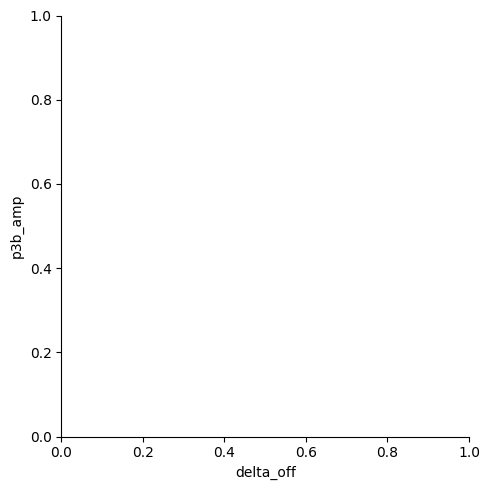

In [41]:
sns.lmplot(
    data=df_clean[df_clean['parent_edu'] == 'mid'],
    x='delta_off',
    y='p3b_amp'
)

In [ ]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df_clean,
    x='exp_post',
    hue='SES_group',
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title('Aperiodic Exponent Distribution by SES Group')
plt.xlabel('Aperiodic Exponent (Post-stimulus)')
plt.ylabel('Density')

plt.show()

In [46]:
# there are no clear differences in aperiodic exponent across SES groups

In [ ]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df_clean,
    x='off_post',
    hue='parent_edu',
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title('Aperiodic Offset Distribution by SES Group')
plt.xlabel('Aperiodic Offset (Post-stimulus)')
plt.ylabel('Density')

plt.show()

In [48]:
# there are no meaningful differences in aperiodic offset across SES groups

In [ ]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df_clean,
    x='exp_post',
    hue='Gender',
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title('Aperiodic Exponent Distribution by Gender')
plt.xlabel('Aperiodic Exponent (Post-stimulus)')
plt.ylabel('Density')

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df_clean,
    x='off_post',
    hue='Gender',
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title('Aperiodic Offset Distribution by Gender')
plt.xlabel('Aperiodic Offset (Post-stimulus, log power)')
plt.ylabel('Density')

plt.show()